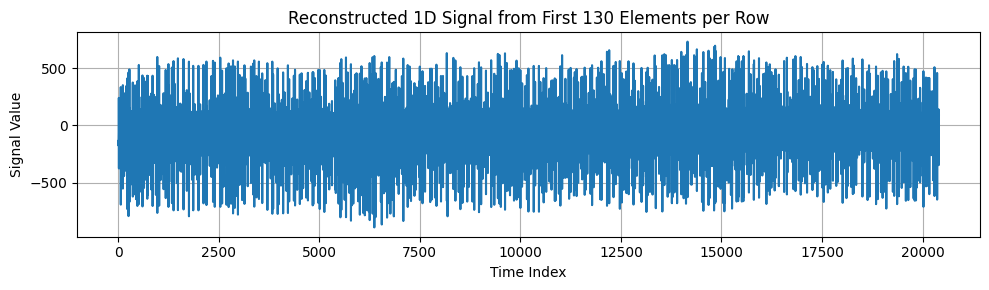

Gaze data shape: (157, 300), Expected per row: 300


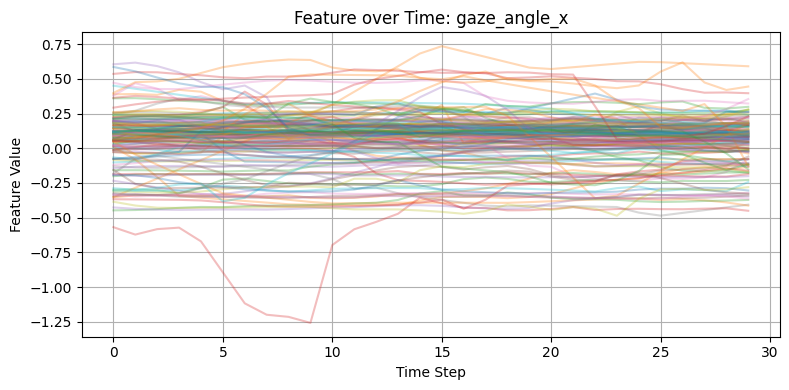

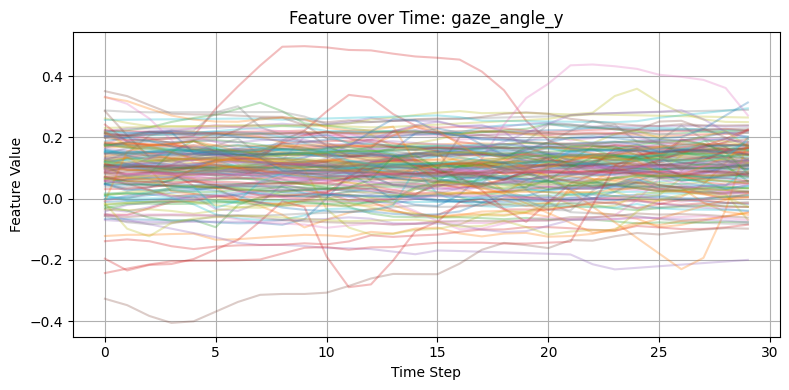

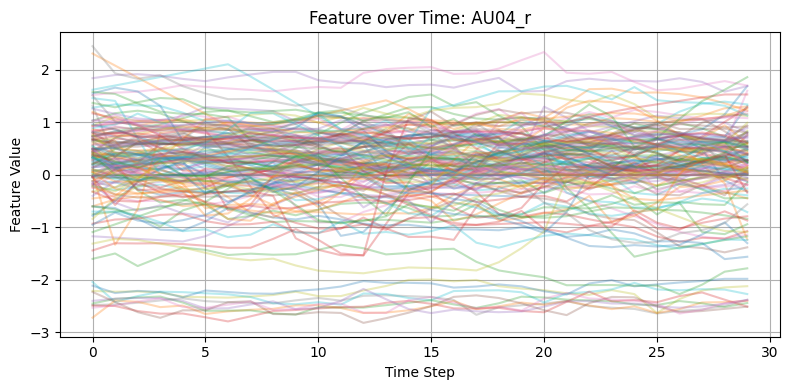

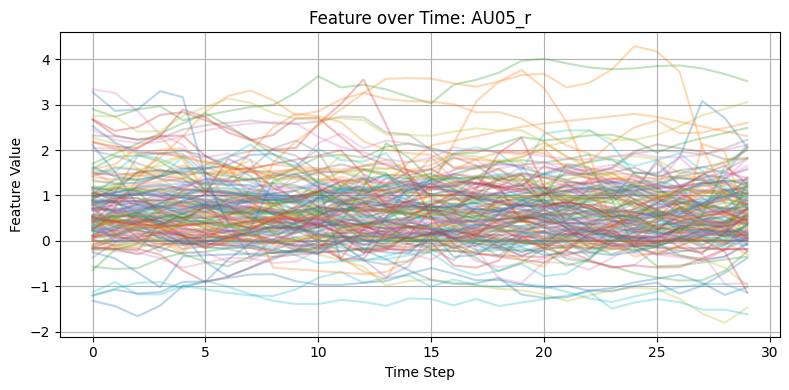

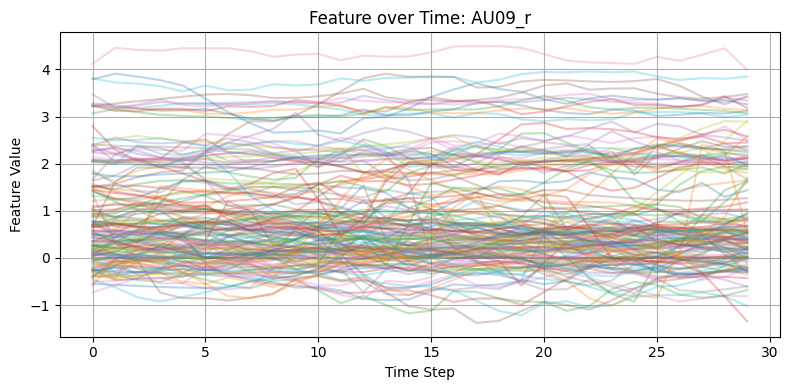

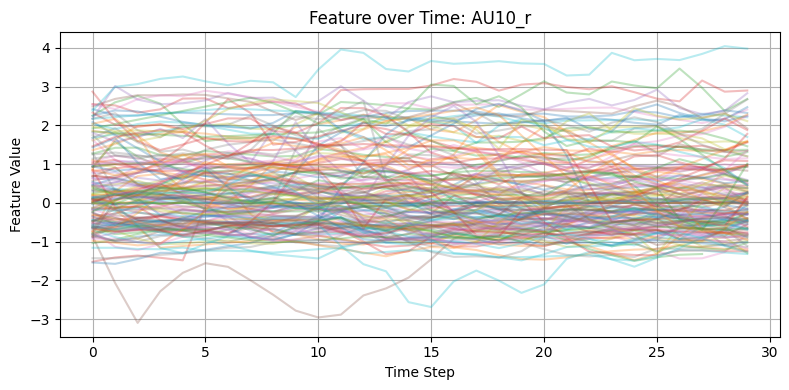

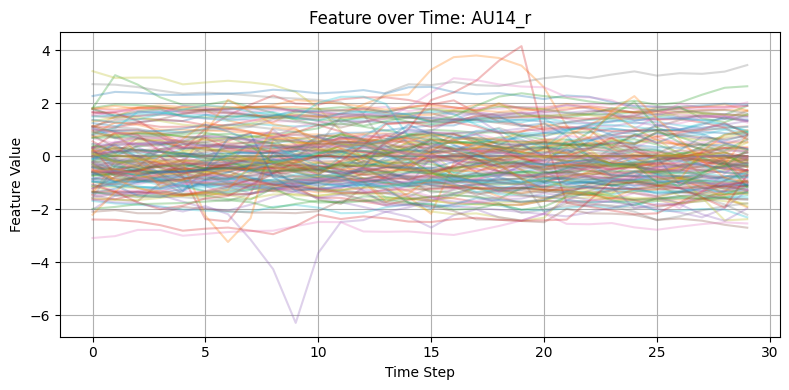

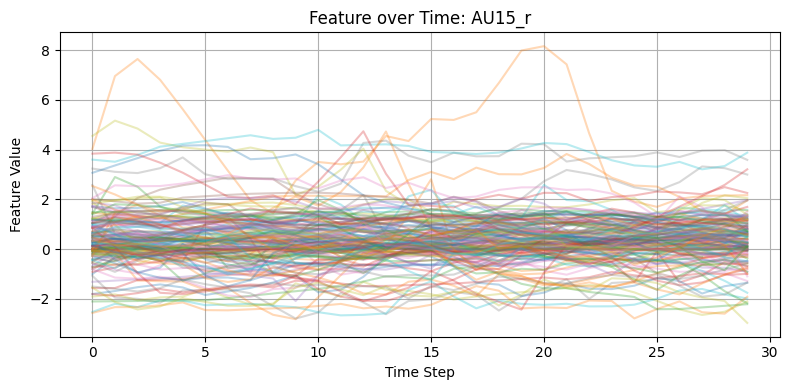

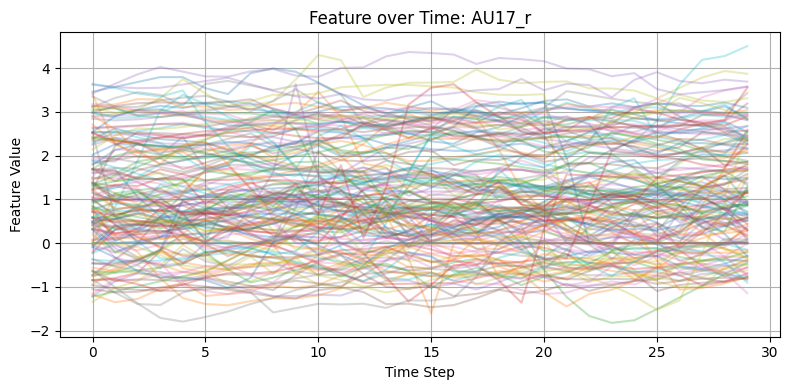

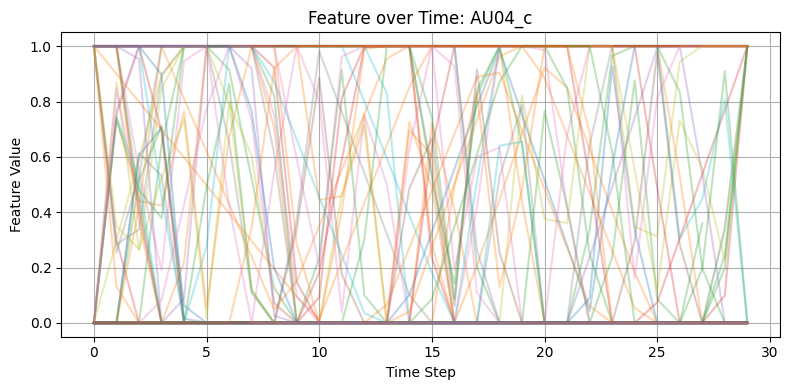

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === CONFIG ===
csv_path = 'aggg.csv'
L = 30  # interpolated time steps
num_features = 10  # or 11
start_index = 130  # where the gaze vector starts
feature_names = [
    'gaze_angle_x', 'gaze_angle_y',
    'AU04_r', 'AU05_r', 'AU09_r', 'AU10_r',
    'AU14_r', 'AU15_r', 'AU17_r', 'AU04_c'
    # Add more if num_features > 10
]

# === LOAD CSV ===
df = pd.read_csv(csv_path)
all_data = df.values

# === 1. Reconstruct and Plot the 1D signal ===
signal_chunks = all_data[:, :start_index]  # shape: (num_rows, 130)
signal = signal_chunks.flatten()  # stacked row-wise into 1D

plt.figure(figsize=(10, 3))
plt.plot(signal)
plt.title("Reconstructed 1D Signal from First 130 Elements per Row")
plt.xlabel("Time Index")
plt.ylabel("Signal Value")
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Plot each feature over time ===
gaze_data = all_data[:, start_index:]  # shape: (num_rows, num_features * L)

print(f"Gaze data shape: {gaze_data.shape}, Expected per row: {L * num_features}")


for i in range(num_features):

    # for row in gaze_data:
    #     if len(row) != L * num_features:
    #         continue

    #     feature_matrix = row.reshape(num_features, L)
    #     values = feature_matrix[i]
    #     print(f"Feature: {feature_names[i]}, Min: {values.min()}, Max: {values.max()}")
    #     plt.plot(values, alpha=0.3)

    plt.figure(figsize=(8, 4))
    for row in gaze_data:
        if len(row) != L * num_features:
            continue  # skip malformed rows
        feature_matrix = row.reshape(num_features, L)
        plt.plot(feature_matrix[i], alpha=0.3)

    plt.title(f"Feature over Time: {feature_names[i]}")
    plt.xlabel("Time Step")
    plt.ylabel("Feature Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
